In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  


In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import geostrophy, density,conversions


In [4]:
sla_ = SLA(deg=0.25).da
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))

In [5]:
landmask =xr.open_dataset('c8517cce57bb168f2aed331b63d10ba3.nc').lsm.squeeze()

In [6]:
lon=landmask.longitude
landmask['longitude'] = lon.where(lon < 180,lon-360)
landmask = landmask.sortby('longitude')

In [7]:
rho_air = 1.225 #kgm-3
c_d = 1.3e-3
u10 = winds_.u10
v10 = winds_.v10
umod = np.sqrt((u10 * u10) + (v10 * v10))

In [25]:


tx1 = rho_air * c_d * umod * winds_.u10
ty1 = rho_air * c_d * umod * winds_.v10

landmask = landmask.interp_like(tx1)

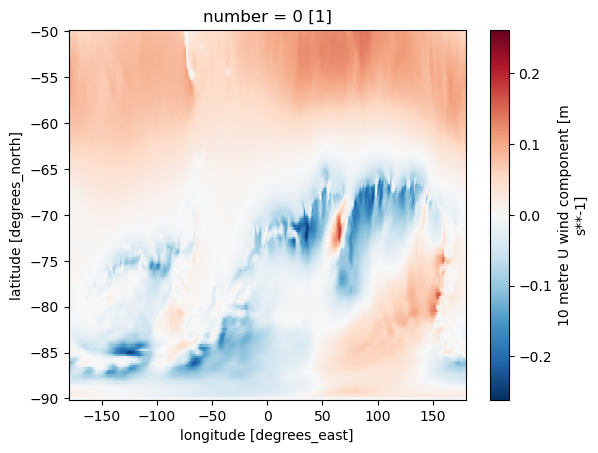

In [ ]:
tx1.mean('time').plot()

In [116]:
tx2 = tx1.where(landmask<0.002,drop=True)
ty2 = ty1.where(landmask<0.002,drop=True)

lat = tx2.latitude
lon = tx2.longitude

In [117]:
lat_rad = np.deg2rad(tx2.latitude)
lon_rad = np.deg2rad(tx2.longitude)

tx = tx2.assign_coords({'longitude': lon_rad, 'latitude': lat_rad})
ty = ty2.assign_coords({'longitude': lon_rad, 'latitude': lat_rad})

In [118]:
dty_dlambda = ty.differentiate('longitude')
dtx_dphi = tx.differentiate('latitude')

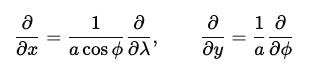

In [119]:
cosphi = np.cos(lat_rad)
# convert to DataArray with lat coord so broadcasting works automatically
cosphi_da = xr.DataArray(cosphi, coords={'latitude': lat_rad}, dims=('latitude',))


In [120]:
a = 6.371e6
aterm = 1 / (a * cosphi_da)
bterm = 1 / a

dty_dx = dty_dlambda * aterm
dtx_dy = dtx_dphi * bterm
curl_ = dty_dx - dtx_dy
curl_ = curl_.assign_coords({'latitude': lat, 'longitude': lon})

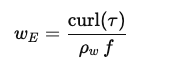

In [121]:
rho_w = 1025
omega = 7.292115e-5
f = 2 * omega * np.sin(lat_rad)
f_da = xr.DataArray(f, coords={'latitude': lat}, dims=('latitude',))

w_ = curl_ / (rho_w * f_da)

In [122]:
gyre_index = xr.open_dataarray('gyre_index.nc')

In [123]:
extent_ac = [138,152,-68,-63]
extent_gyre = [145,150,-66.5,-65.5]
extent_ea=[60,160,-70,-60]
elevation = fns.elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))

region_ac = Region('AC',extent_ac,elevation=elevation)

In [124]:
sla = region_ac.crop_da(sla_)
sice = region_ac.crop_da(sice_)
winds = region_ac.crop_da(winds_)
curl = region_ac.crop_da(curl_)
w = region_ac.crop_da(w_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

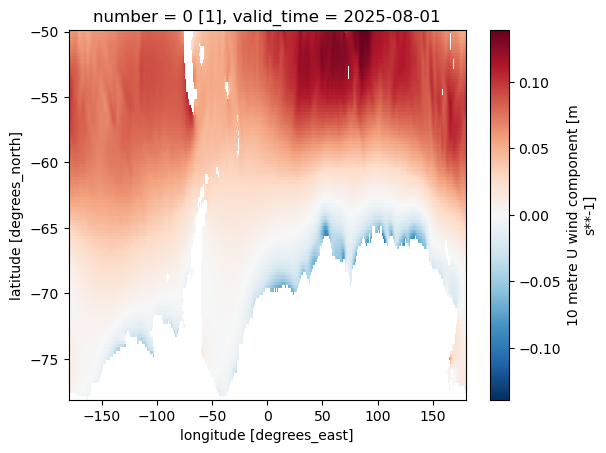

In [125]:
tx2.mean('time').plot()

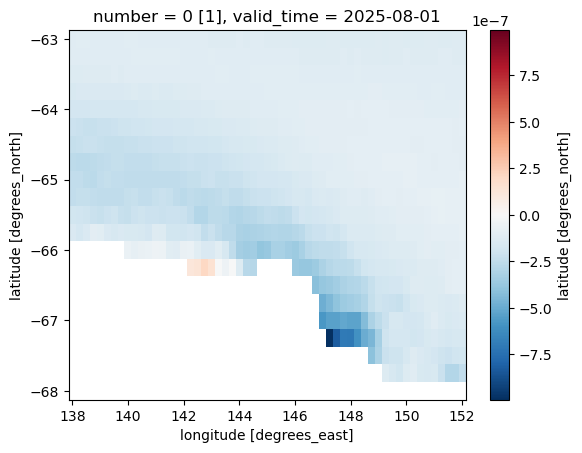

In [126]:
curl.mean('time').plot()

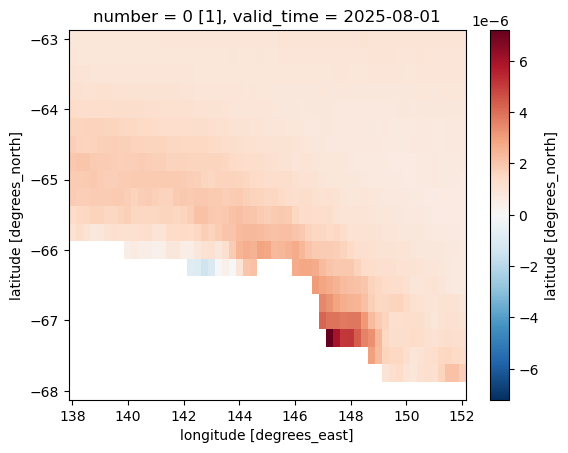

In [127]:
w.mean('time').plot()

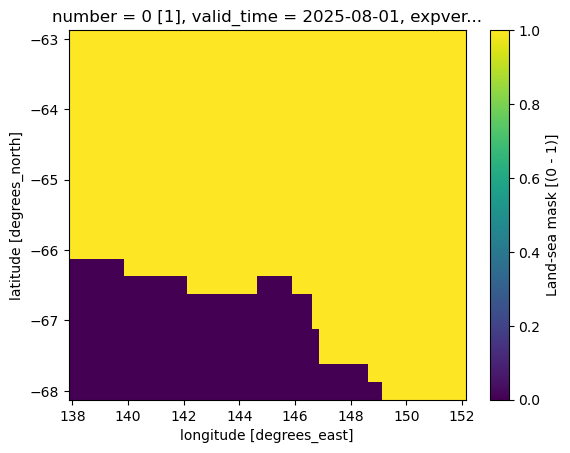

In [128]:
region_ac.crop_da(landmask < 0.002).plot()

In [129]:
u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [130]:
dsice = sice.differentiate('time')

In [131]:
sa_sic = fns.seasonal_anomaly(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_dsc = fns.seasonal_anomaly(dsice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sla = fns.seasonal_anomaly(sla.interpolate_na(dim='time'))
sa_geos = fns.seasonal_anomaly(geos.interpolate_na(dim='time'))
sa_winds = fns.seasonal_anomaly(winds.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_gyre = fns.seasonal_anomaly(gyre_index)
sa_curl = fns.seasonal_anomaly(curl)
sa_w = fns.seasonal_anomaly(w)

ssn_gyre = fns.season_split(sa_gyre)

ssn_sla = fns.season_split(sa_sla)
ssn_geos = fns.season_split(sa_geos)
ssn_sic = fns.season_split(sa_sic)
ssn_dsc = fns.season_split(sa_dsc)
ssn_winds = fns.season_split(sa_winds)
ssn_curl = fns.season_split(sa_curl)
ssn_w = fns.season_split(sa_w)

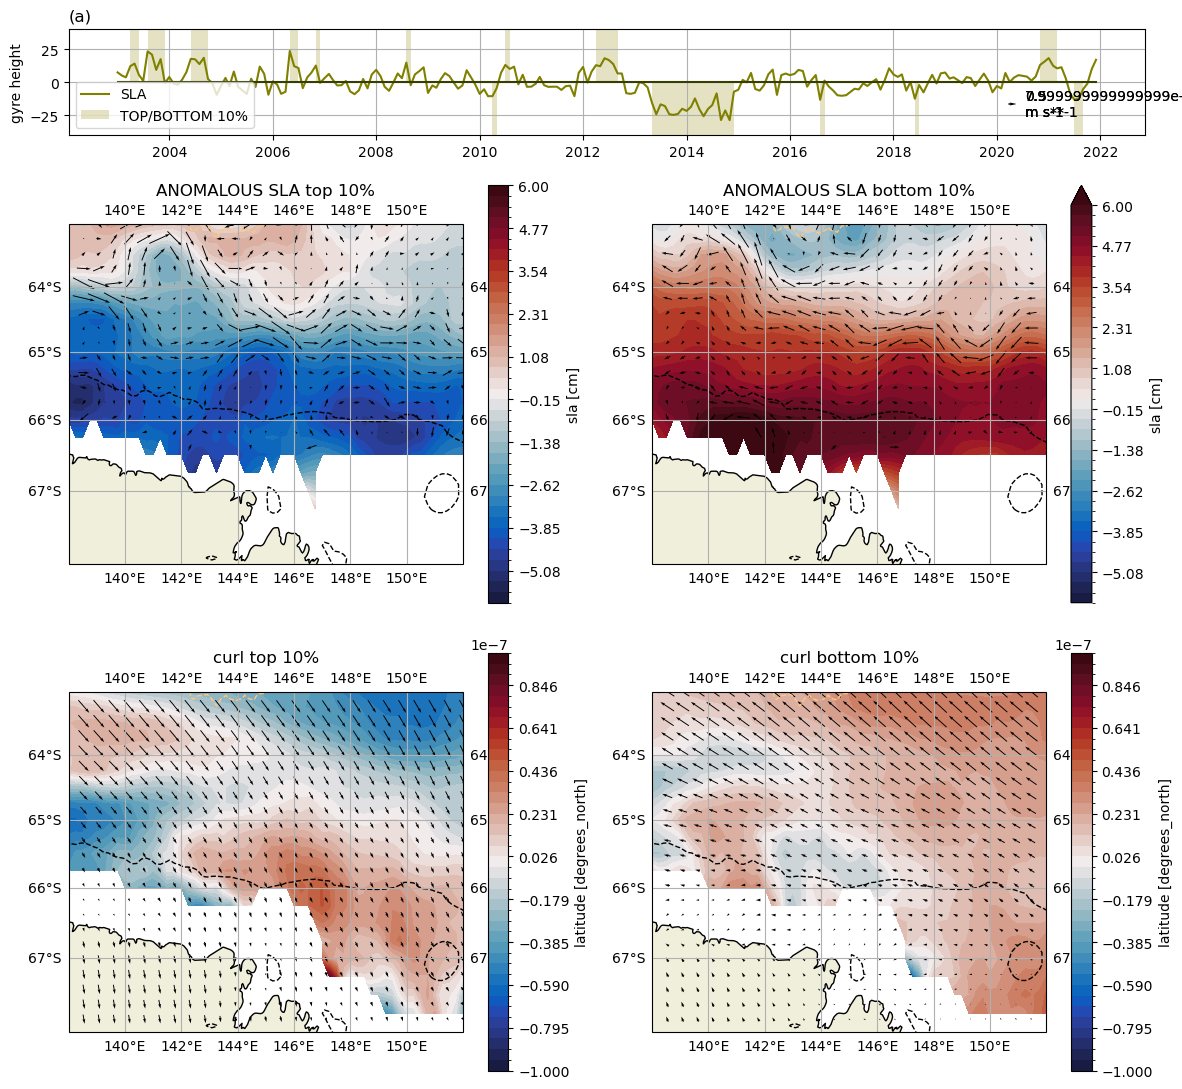

In [132]:
fns.run_for_idx(sa_gyre,0.1,sa_sla,sa_geos,'ANOMALOUS SLA',extent_ac,ylim_idx=40,da2=sa_curl,da_vector2=sa_winds,da_title2='curl',ylim1=6,ylim2=0.0000001)

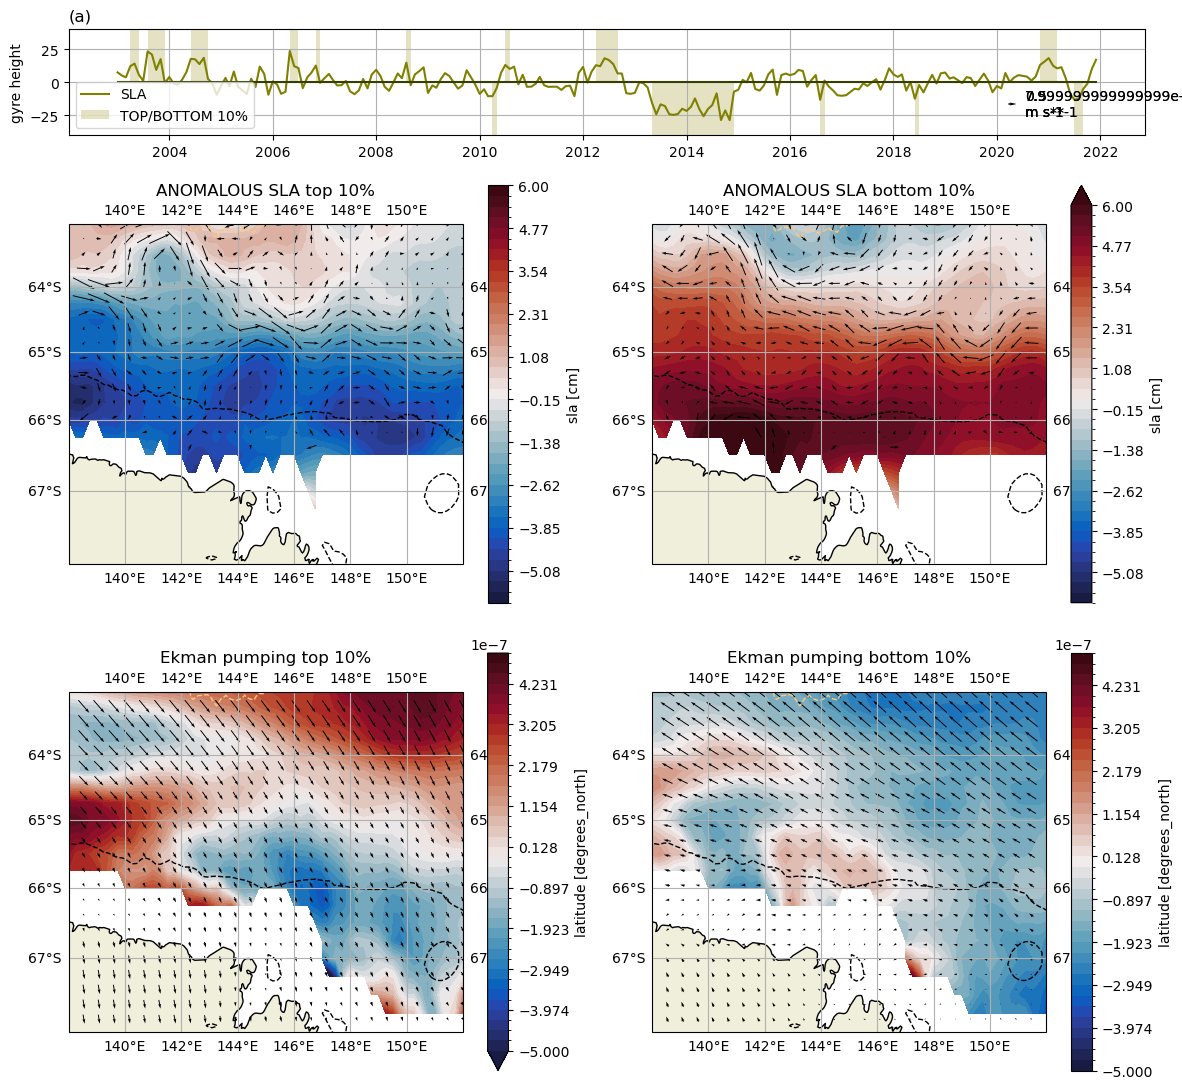

In [133]:
fns.run_for_idx(sa_gyre,0.1,sa_sla,sa_geos,'ANOMALOUS SLA',extent_ac,ylim_idx=40,da2=sa_w,da_vector2=sa_winds,da_title2='Ekman pumping',ylim2=0.0000005,ylim1=6)

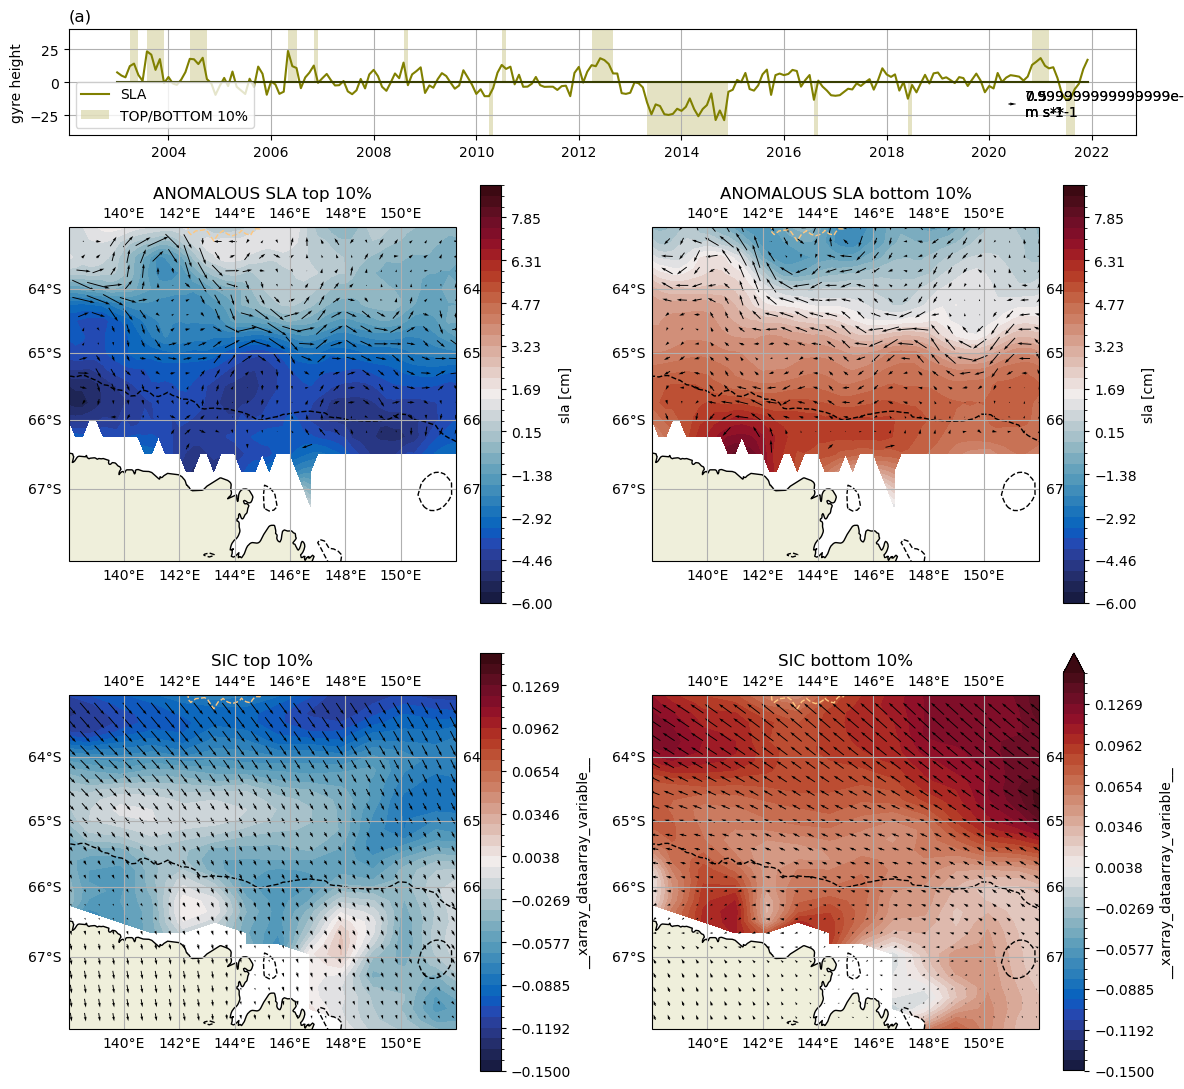

In [11]:
fns.run_for_idx(sa_gyre,0.1,sa_sla,sa_geos,'ANOMALOUS SLA',extent_ac,ylim=40,da2=sa_sic,da_vector2=sa_winds,da_title2='SIC',ylim2=0.15)

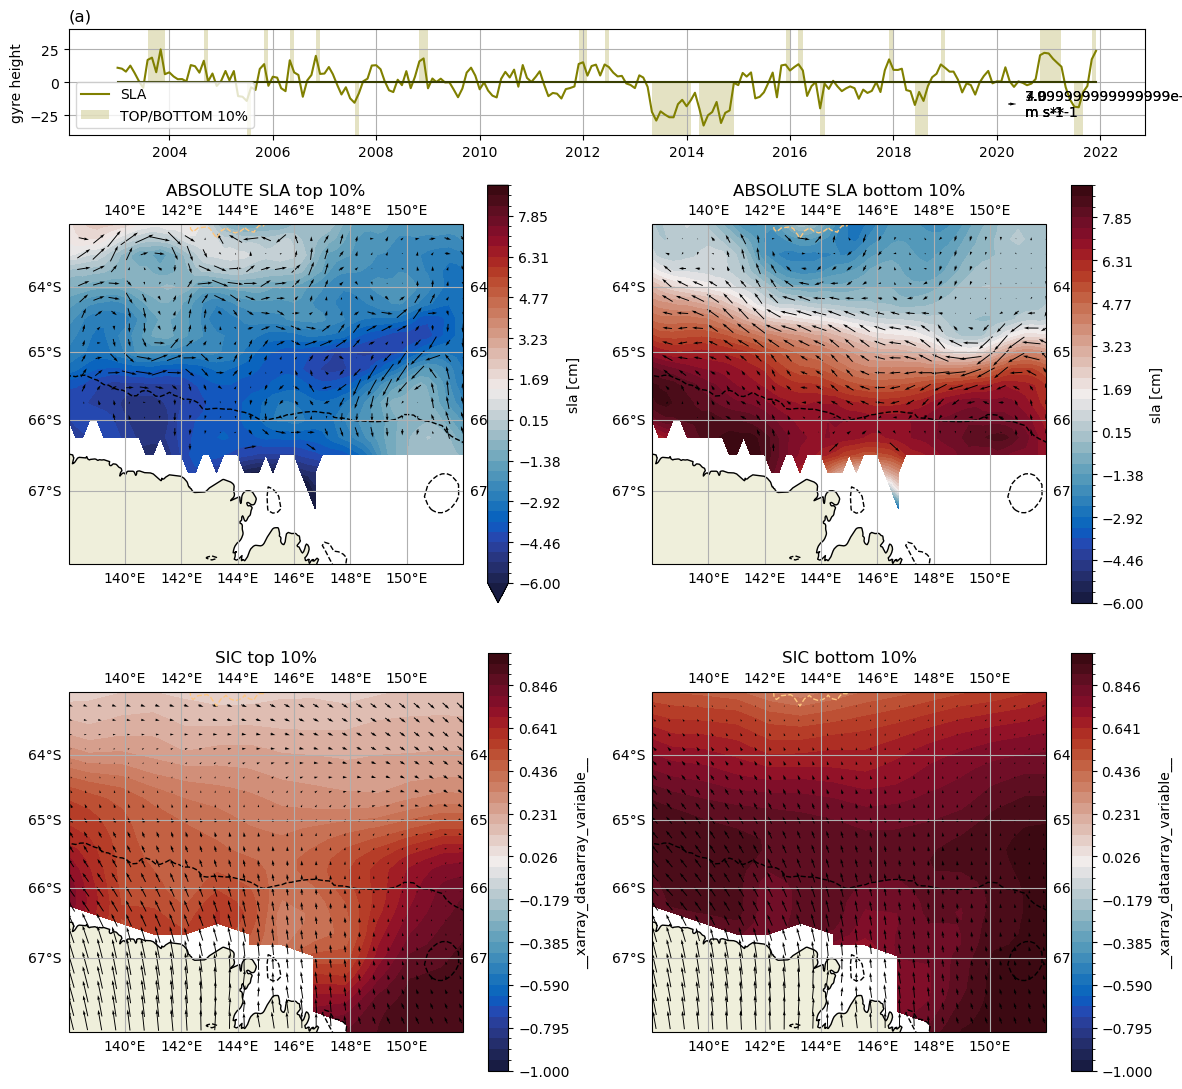

In [12]:
fns.run_for_idx(gyre_index,0.1,sla,geos,'ABSOLUTE SLA',extent_ac,ylim=40,da2=sice,da_vector2=winds,da_title2='SIC',ylim2=1)

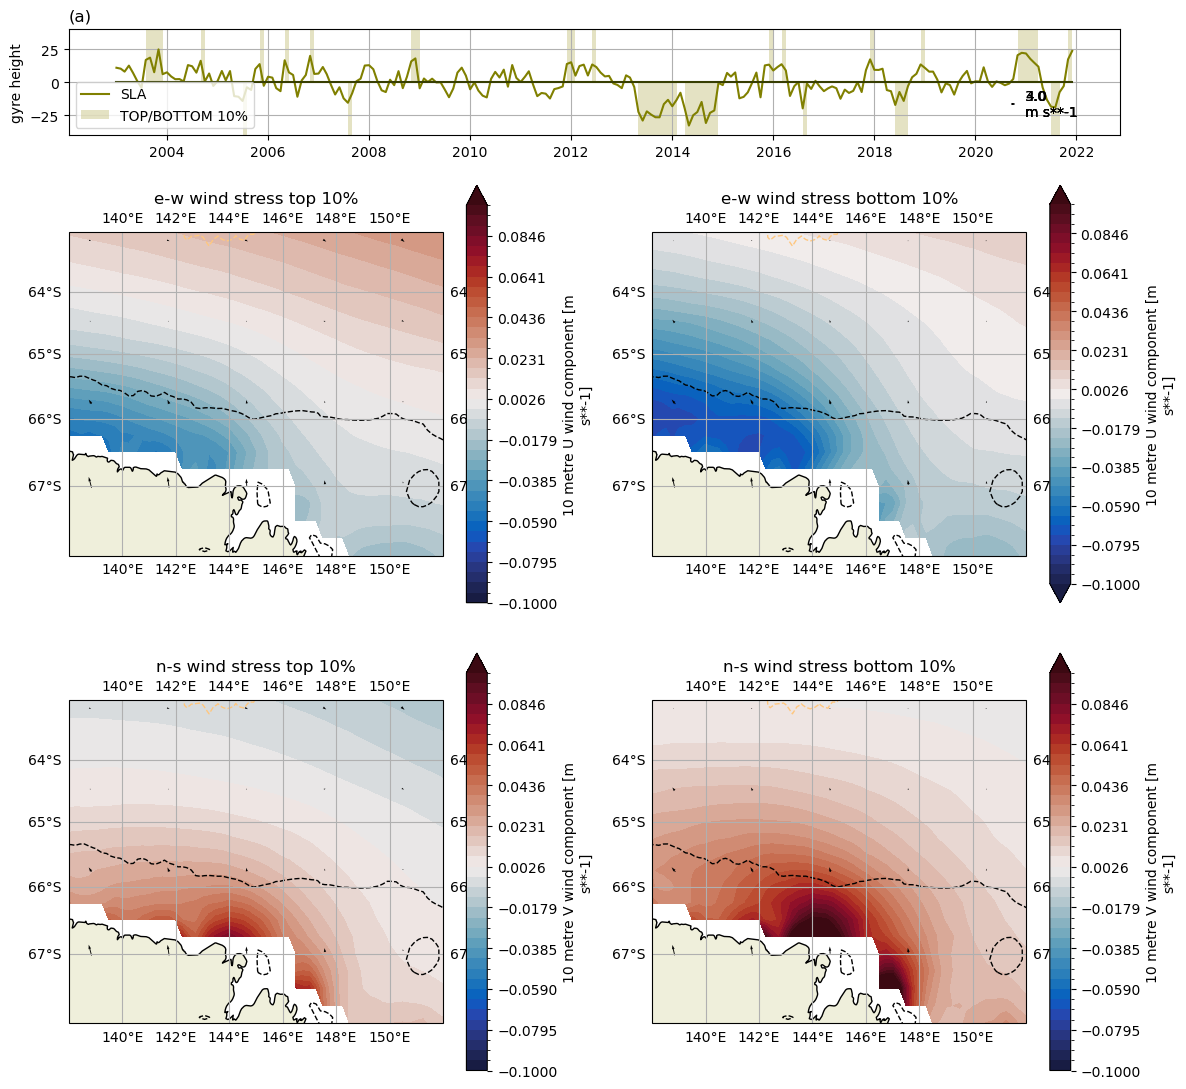

In [111]:
fns.run_for_idx(gyre_index,0.1,tx2,winds,'e-w wind stress',extent_ac,ylim_idx=40,da2=ty2,da_vector2=winds,da_title2='n-s wind stress',ylim1=0.1,ylim2=0.1)

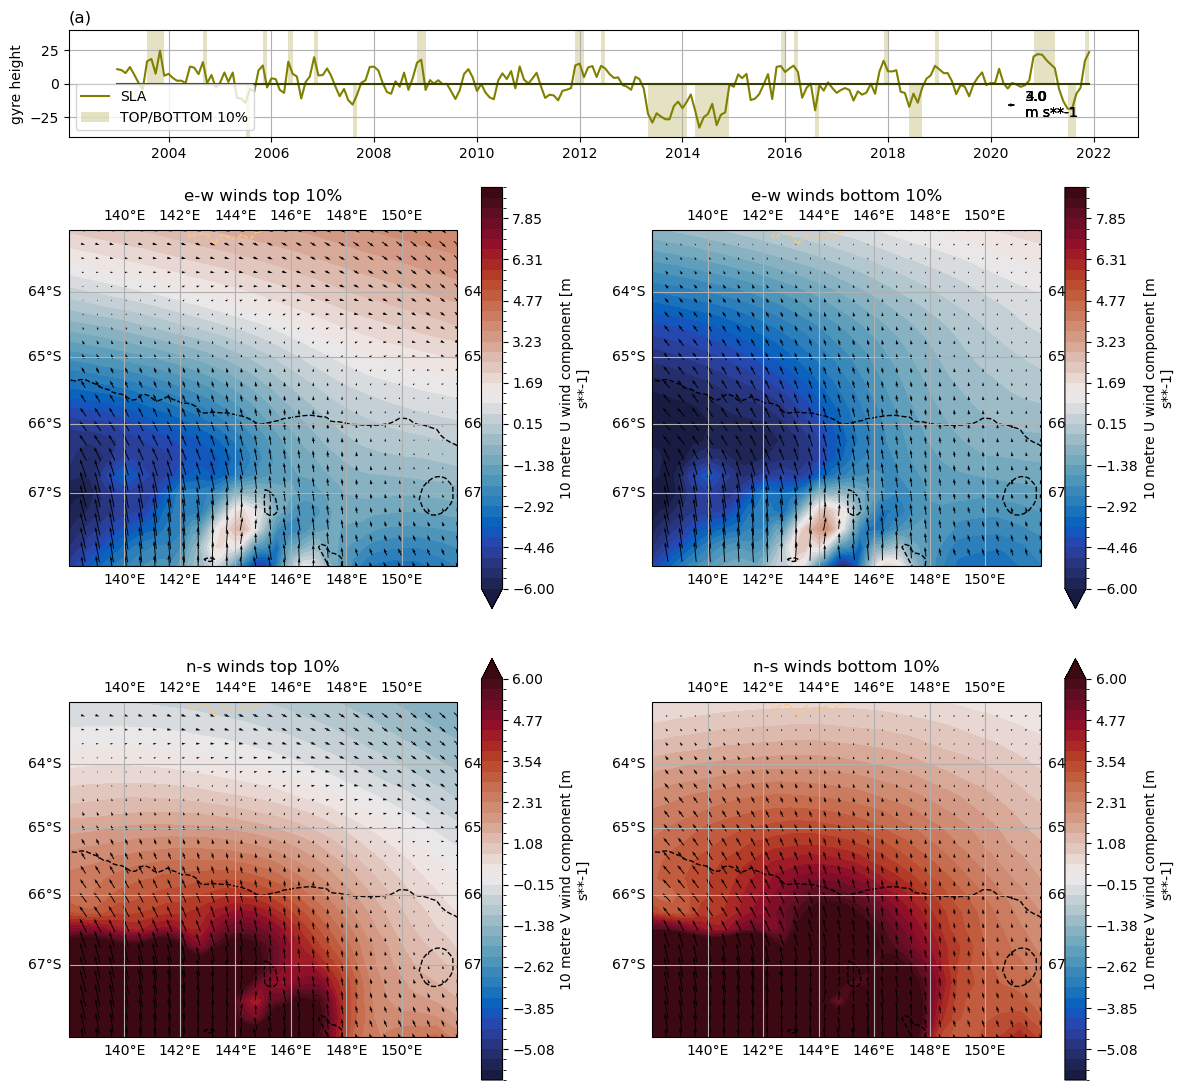

In [13]:
fns.run_for_idx(gyre_index,0.1,winds.u10,winds,'e-w winds',extent_ac,ylim=40,da2=winds.v10,da_vector2=winds,da_title2='n-s winds',ylim2=6)

In [24]:
def latcorr(data):
    cu = []
    cv = []
    for la in data.latitude:
        cu.append(xr.corr(data.u10.sel(latitude=la),gyre_index).item())
        cv.append(xr.corr(data.v10.sel(latitude=la),gyre_index).item())
    return cu, cv


/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: Run

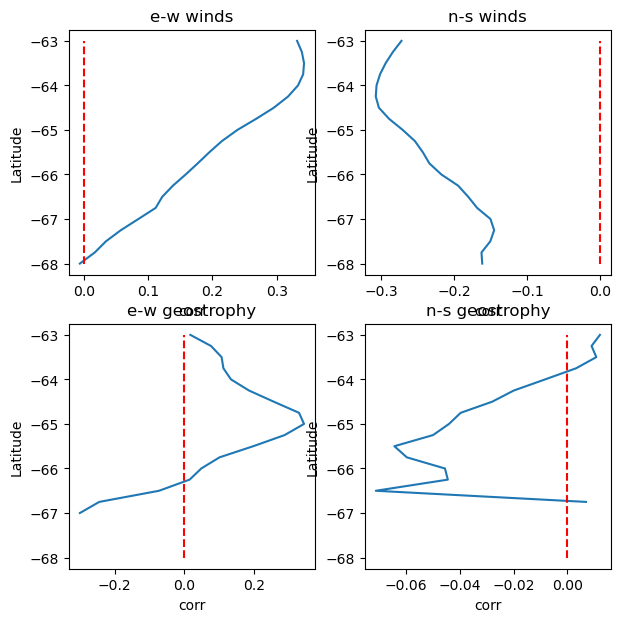

In [26]:
fig, axs = plt.subplots(2,2,figsize=(7,7))
gu,gv = latcorr(geos)
wu,wv = latcorr(winds)

def plotlc(cc,la,ax,lbl):
    ax.plot(cc,la)
    ax.plot([0 for _ in la],la,c='r',ls='--')
    ax.set_ylabel('Latitude')
    ax.set_xlabel('corr')
    ax.set_title(lbl)

plotlc(wu,winds.latitude,axs[0][0],'e-w winds')
plotlc(wv,winds.latitude,axs[0][1],'n-s winds')
plotlc(gu,geos.latitude,axs[1][0],'e-w geostrophy')
plotlc(gv,geos.latitude,axs[1][1],'n-s geostrophy')


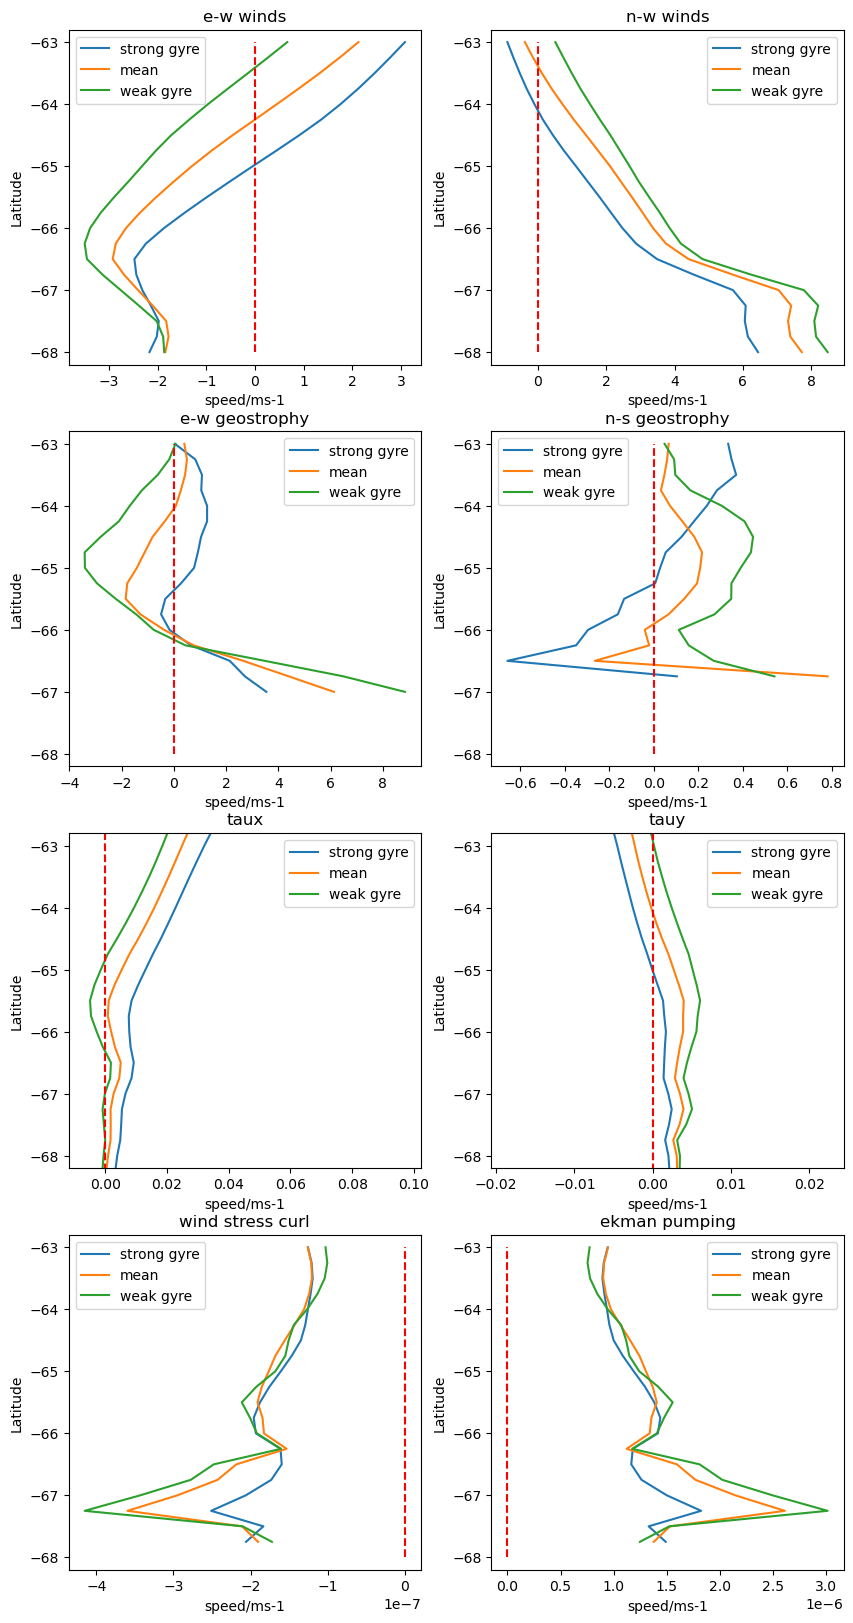

In [135]:
topboo, botboo, top, bot = fns.get_topbot(gyre_index,0.1)

fig, axs = plt.subplots(4,2,figsize=(10,20))


def plot_vec(data,ax,lbl):
    topd = top(data)
    botd = bot(data)
    ax.plot(topd.mean('longitude'),data.latitude,label='strong gyre')
    ax.plot(data.mean(['longitude','time']),data.latitude,label='mean')
    ax.plot(botd.mean('longitude'),data.latitude,label='weak gyre')
    ax.plot([0 for _ in data.latitude],data.latitude,c='r',ls='--')
    ax.set_ylabel('Latitude')
    ax.set_title(lbl)
    ax.set_xlabel('speed/ms-1')
    ax.legend()
    ax.set_ylim([-68.2,-62.8])

plot_vec(winds.u10,axs[0][0],'e-w winds')
plot_vec(winds.v10,axs[0][1],'n-w winds')
plot_vec(geos.u10,axs[1][0],'e-w geostrophy')
plot_vec(geos.v10,axs[1][1],'n-s geostrophy')

plot_vec(tx2,axs[2][0],'taux')
plot_vec(ty2,axs[2][1],'tauy')
plot_vec(curl,axs[3][0],'wind stress curl')
plot_vec(w,axs[3][1],'ekman pumping')



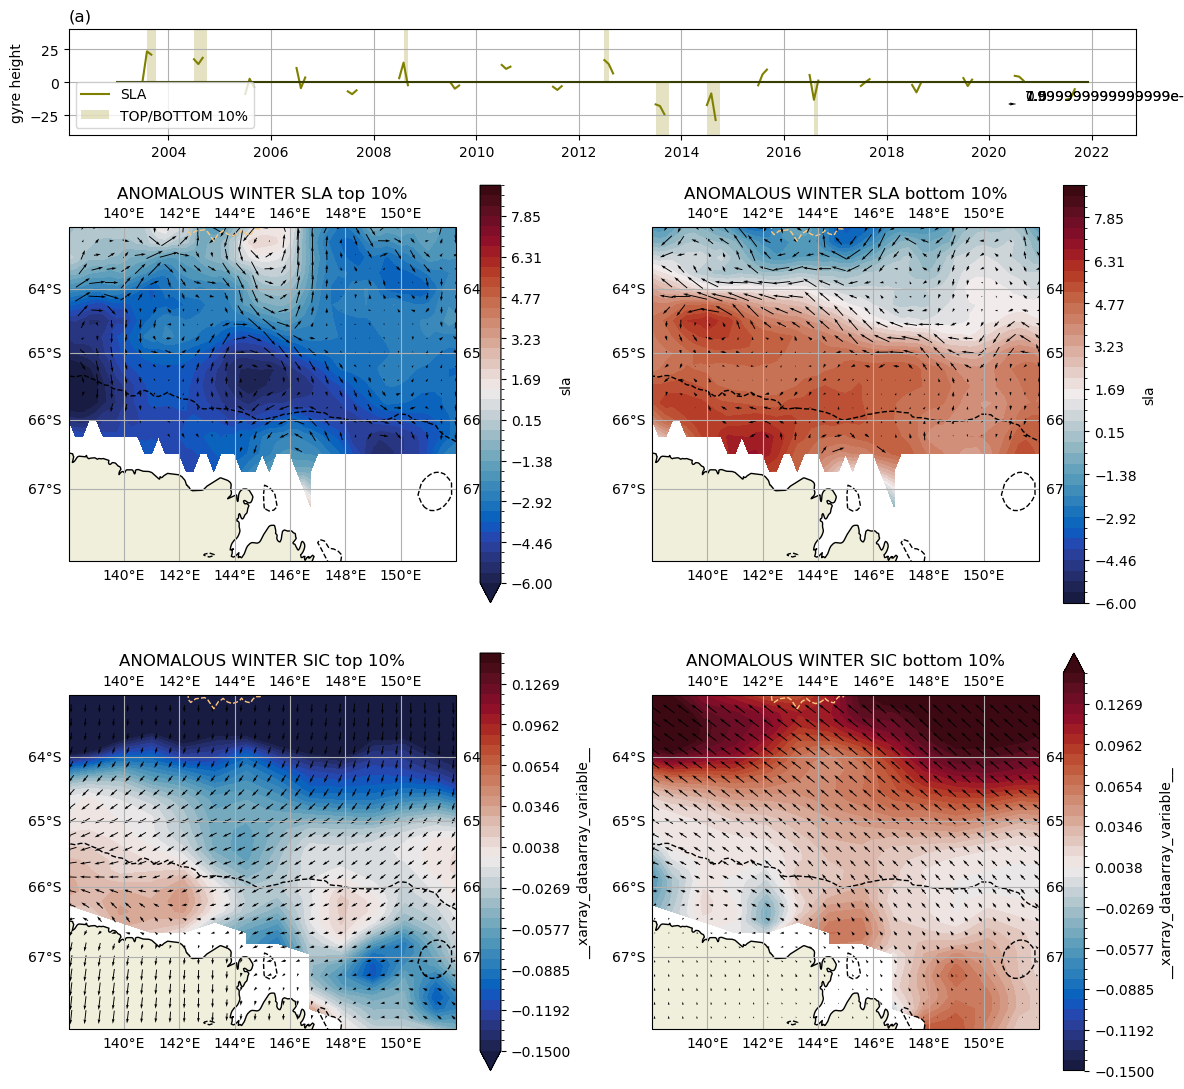

In [23]:
s='winter'
fns.run_for_idx(ssn_gyre[s],0.1,ssn_sla[s],ssn_geos[s],'ANOMALOUS WINTER SLA',extent_ac,ylim=40,da2=ssn_sic[s],da_vector2=ssn_winds[s],da_title2='ANOMALOUS WINTER SIC',ylim2=0.15)

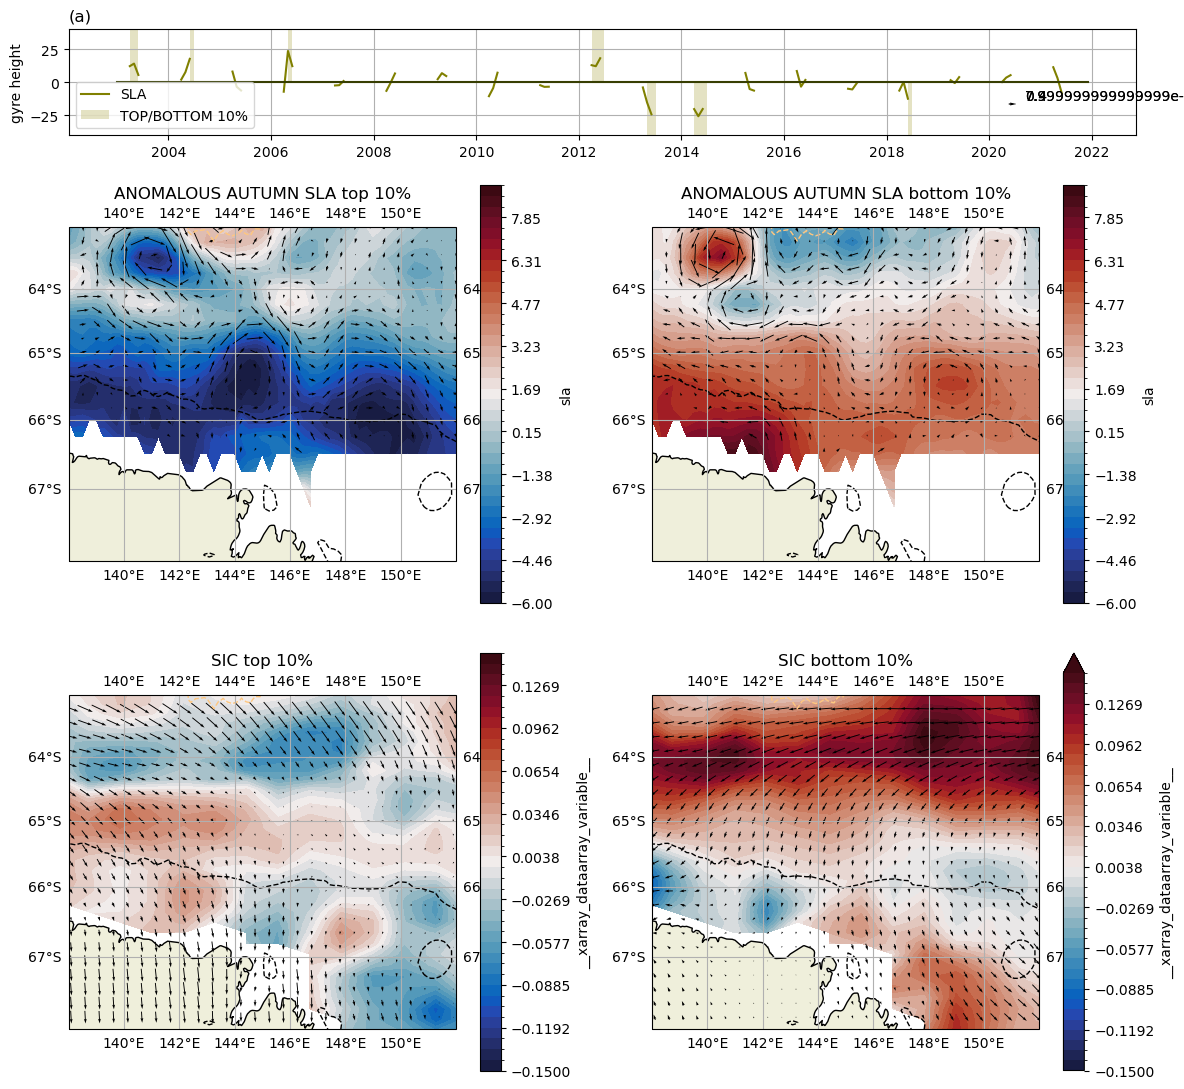

In [22]:
s='autumn'
fns.run_for_idx(ssn_gyre[s],0.1,ssn_sla[s],ssn_geos[s],'ANOMALOUS AUTUMN SLA',extent_ac,ylim=40,da2=ssn_sic[s],da_vector2=ssn_winds[s],da_title2='SIC',ylim2=0.15)


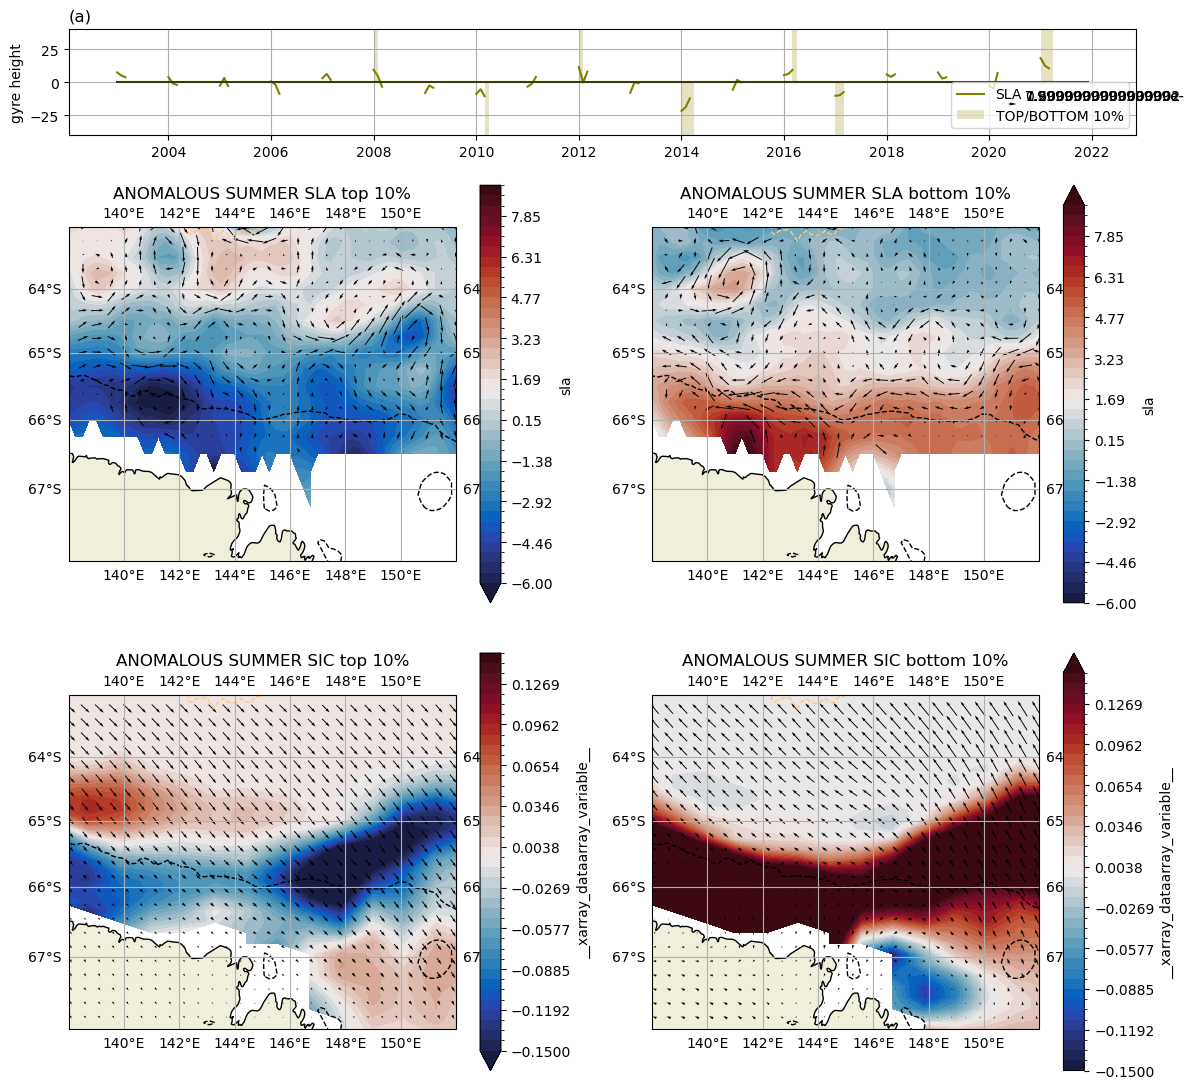

In [24]:
s='summer'
fns.run_for_idx(ssn_gyre[s],0.1,ssn_sla[s],ssn_geos[s],'ANOMALOUS SUMMER SLA',extent_ac,ylim=40,da2=ssn_sic[s],da_vector2=ssn_winds[s],da_title2='ANOMALOUS SUMMER SIC',ylim2=0.15)

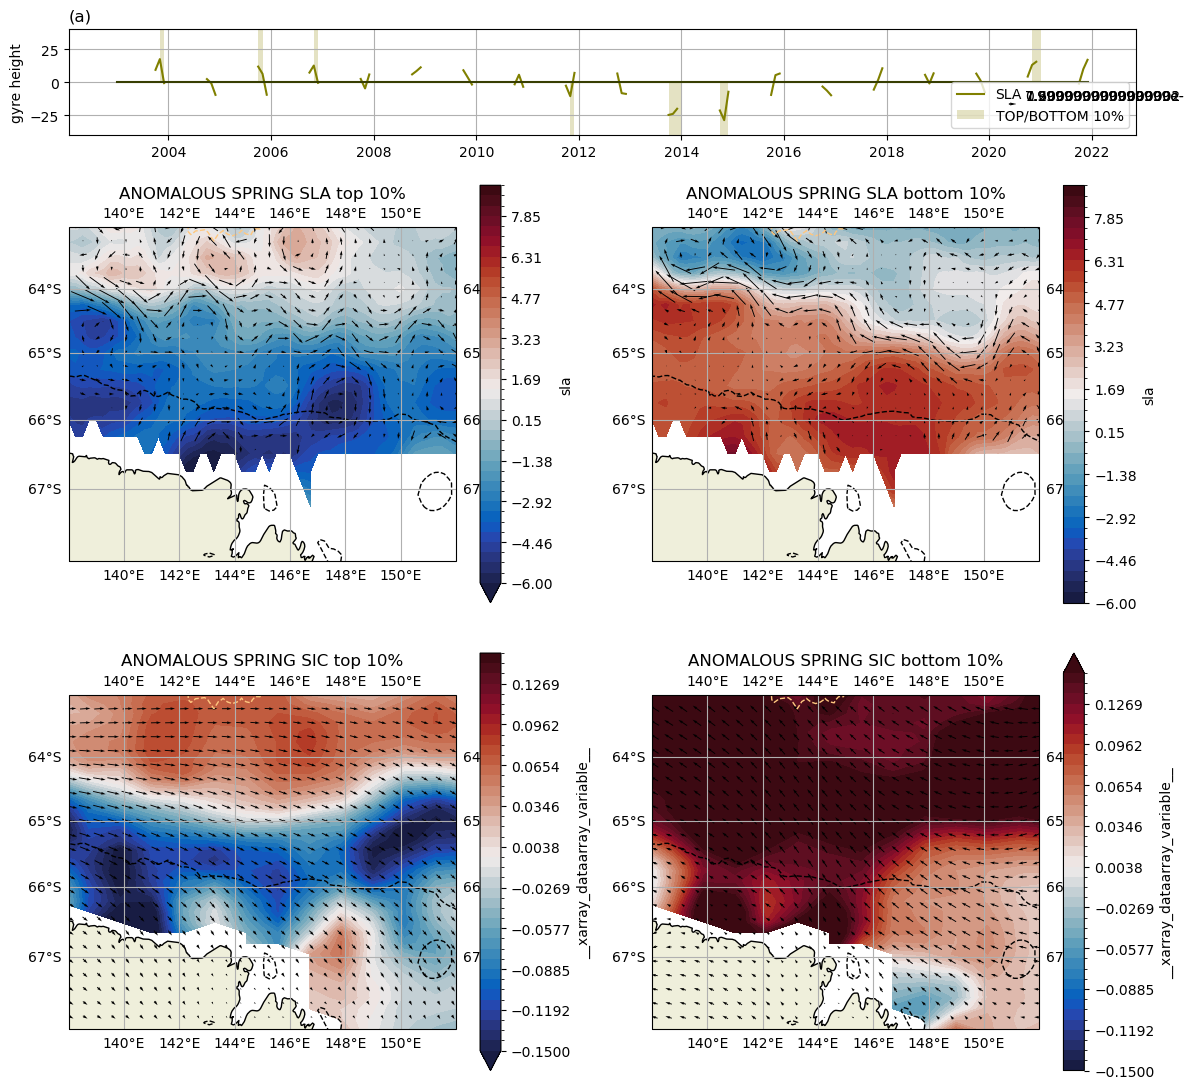

In [25]:
s='spring'
fns.run_for_idx(ssn_gyre[s],0.1,ssn_sla[s],ssn_geos[s],'ANOMALOUS SPRING SLA',extent_ac,ylim=40,da2=ssn_sic[s],da_vector2=ssn_winds[s],da_title2='ANOMALOUS SPRING SIC',ylim2=0.15)

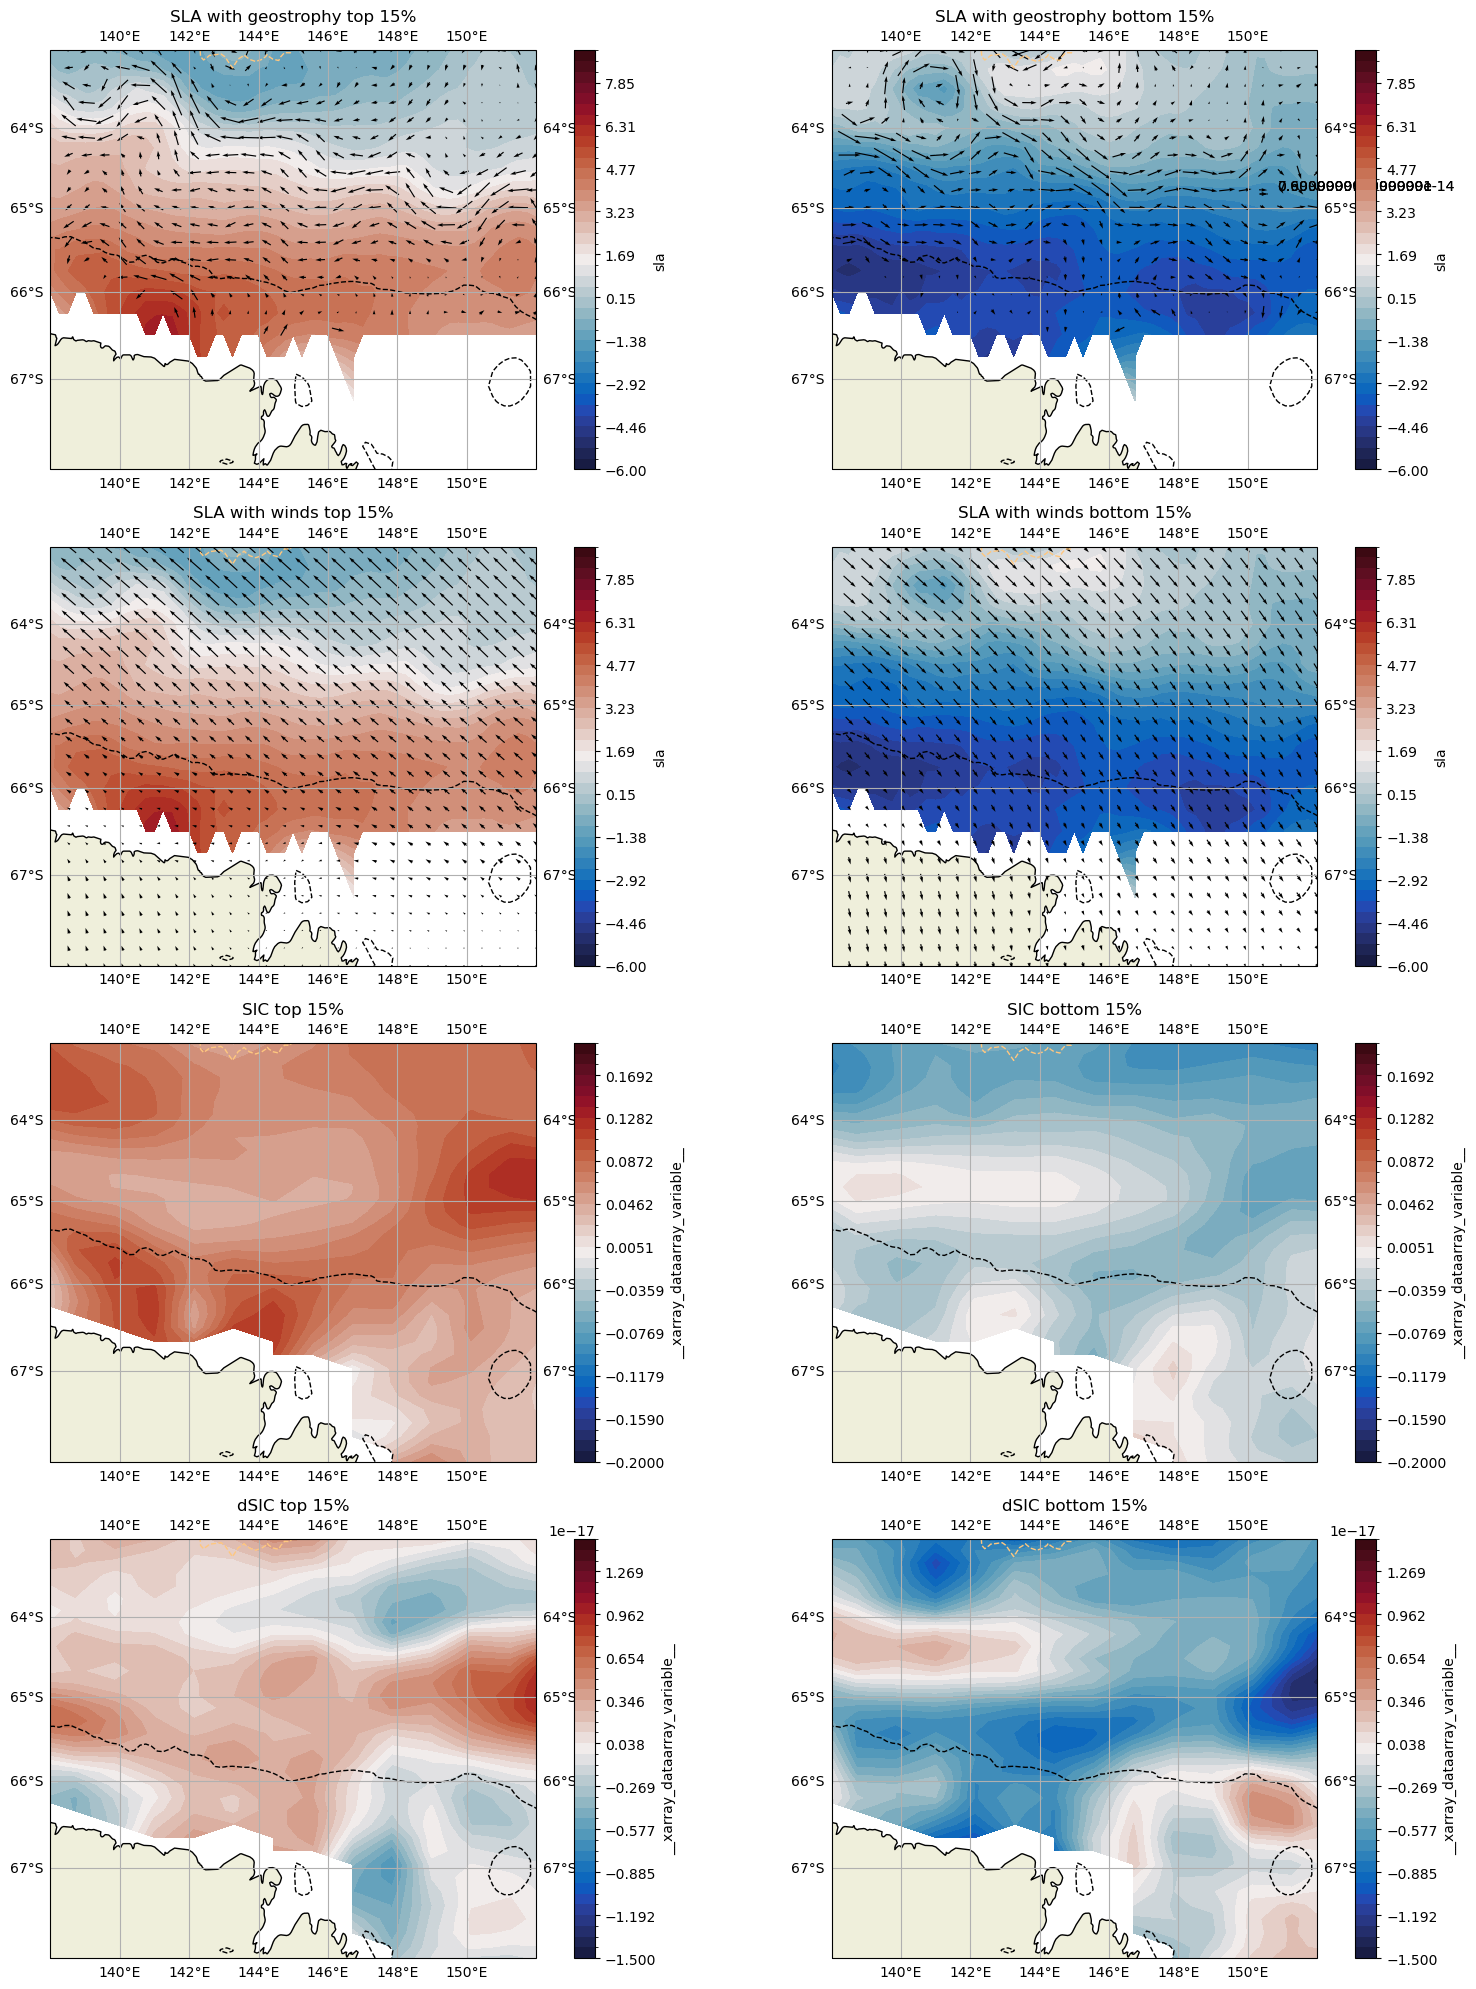

In [15]:
frac = 0.15
topboo, botboo, top, bot = fns.get_topbot(sa_gyre_se,frac)
perc = int(frac*100)

fig,ax = plt.subplots(4,2,figsize=(16,20),subplot_kw={'projection':ccrs.Mercator()})

# sla
fns.plotc(ax[0][0],top(sa_sla),'{} top {}%'.format('SLA with geostrophy',perc),extent_ac,-6,9,vector=top(sa_geos))
fns.plotc(ax[0][1],bot(sa_sla),'{} bottom {}%'.format('SLA with geostrophy',perc),extent_ac,-6,9,vector=bot(sa_geos))

# sla
fns.plotc(ax[1][0],top(sa_sla),'{} top {}%'.format('SLA with winds',perc),extent_ac,-6,9,vector=top(sa_winds))
fns.plotc(ax[1][1],bot(sa_sla),'{} bottom {}%'.format('SLA with winds',perc),extent_ac,-6,9,vector=bot(sa_winds))

# sic
n = 0.2
fns.plotc(ax[2][0],top(sa_sic),'{} top {}%'.format('SIC',perc),extent_ac,-n,n)
fns.plotc(ax[2][1],bot(sa_sic),'{} bottom {}%'.format('SIC',perc),extent_ac,-n,n)

# dsc
n = 1.5e-17
fns.plotc(ax[3][0],top(sa_dsc),'{} top {}%'.format('dSIC',perc),extent_ac,-n,n)
fns.plotc(ax[3][1],bot(sa_dsc),'{} bottom {}%'.format('dSIC',perc),extent_ac,-n,n)



plt.tight_layout()

ValueError: Dimensions {'mode'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'longitude': 57, 'latitude': 21, 'time': 228})

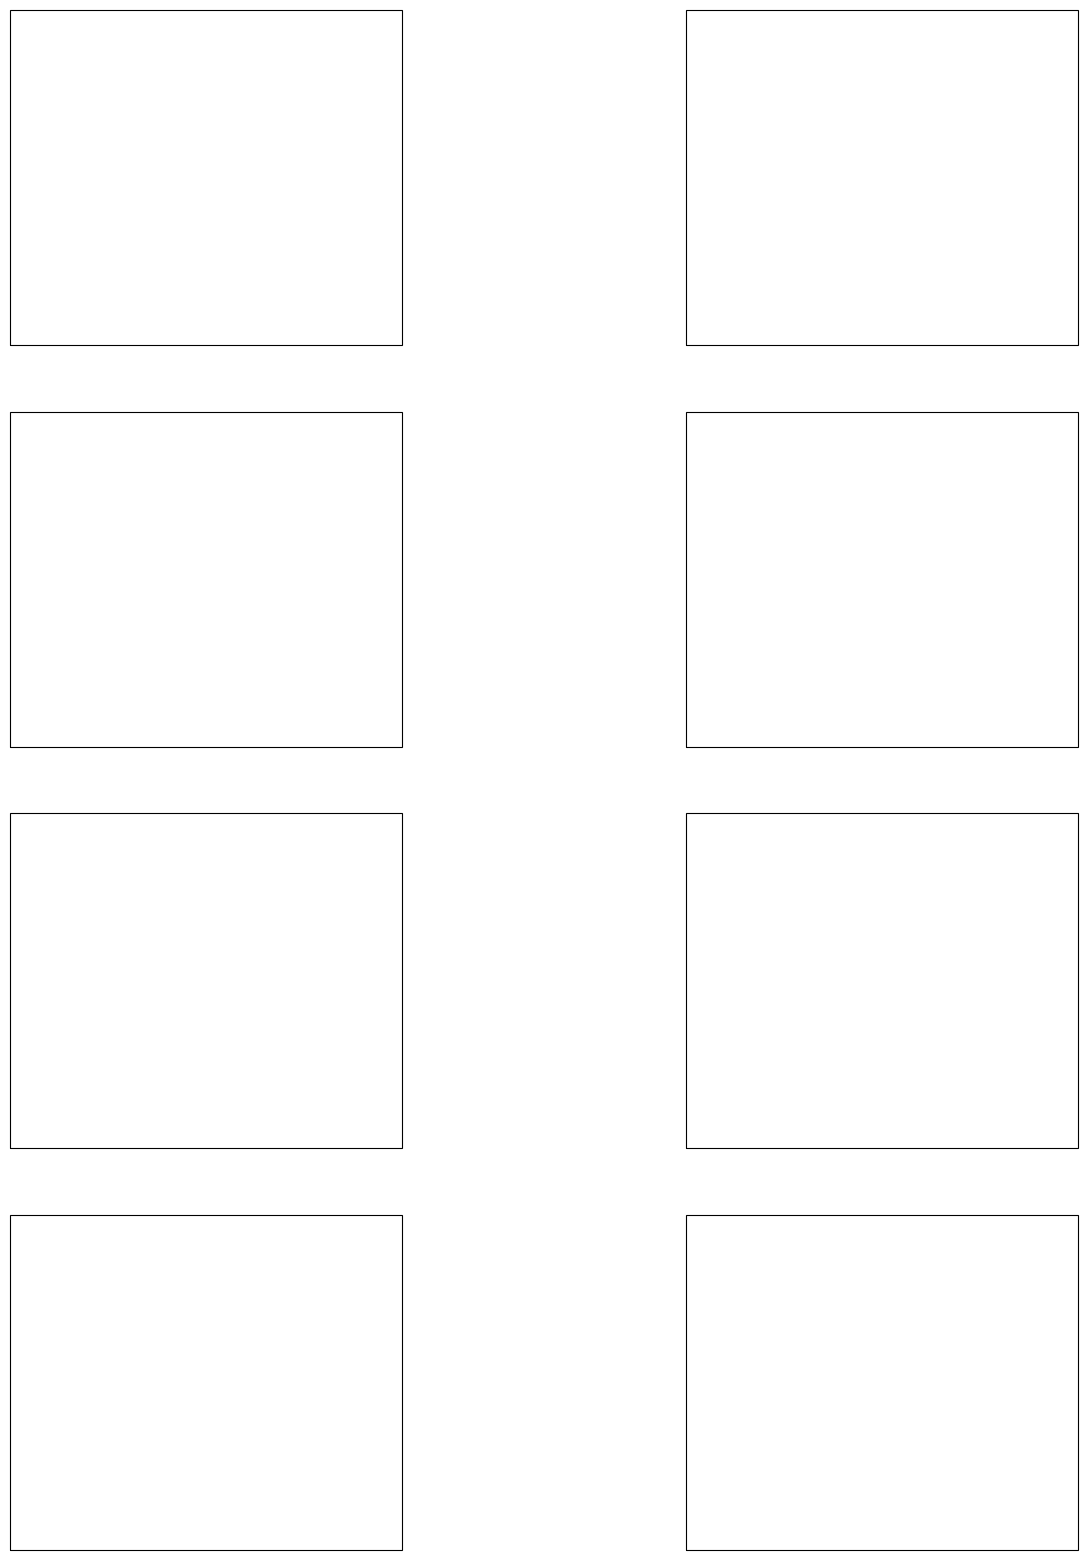

In [13]:
frac = 0.15
topboo, botboo, top, bot = fns.get_topbot(sa_gyre,frac)
perc = int(frac*100)

fig,ax = plt.subplots(4,2,figsize=(16,20),subplot_kw={'projection':ccrs.Mercator()})

# sla
fns.plotc(ax[0][0],top(sa_sla),'{} top {}%'.format('SLA with geostrophy',perc),extent_ac,-6,9,vector=top(sa_geos))
fns.plotc(ax[0][1],bot(sa_sla),'{} bottom {}%'.format('SLA with geostrophy',perc),extent_ac,-6,9,vector=bot(sa_geos))

# sla
fns.plotc(ax[1][0],top(sa_sla),'{} top {}%'.format('SLA with winds',perc),extent_ac,-6,9,vector=top(sa_winds))
fns.plotc(ax[1][1],bot(sa_sla),'{} bottom {}%'.format('SLA with winds',perc),extent_ac,-6,9,vector=bot(sa_winds))

lag = 0
# sic
n = 0.2
ttl = 'SIC with {}-month lag'.format(lag)
fns.plotc(ax[2][0],top(sa_sic,lag),'{} top {}%'.format(ttl,perc),extent_ac,-n,n)
fns.plotc(ax[2][1],bot(sa_sic,lag),'{} bottom {}%'.format(ttl,perc),extent_ac,-n,n)

# dsc
n = 1.5e-17
ttl = 'dSIC with {}-month lag'.format(lag)
fns.plotc(ax[3][0],top(sa_dsc,lag),'{} top {}%'.format(ttl,perc),extent_ac,-n,n)
fns.plotc(ax[3][1],bot(sa_dsc,lag),'{} bottom {}%'.format(ttl,perc),extent_ac,-n,n)

plt.tight_layout()

(-4000.0, 0.0)

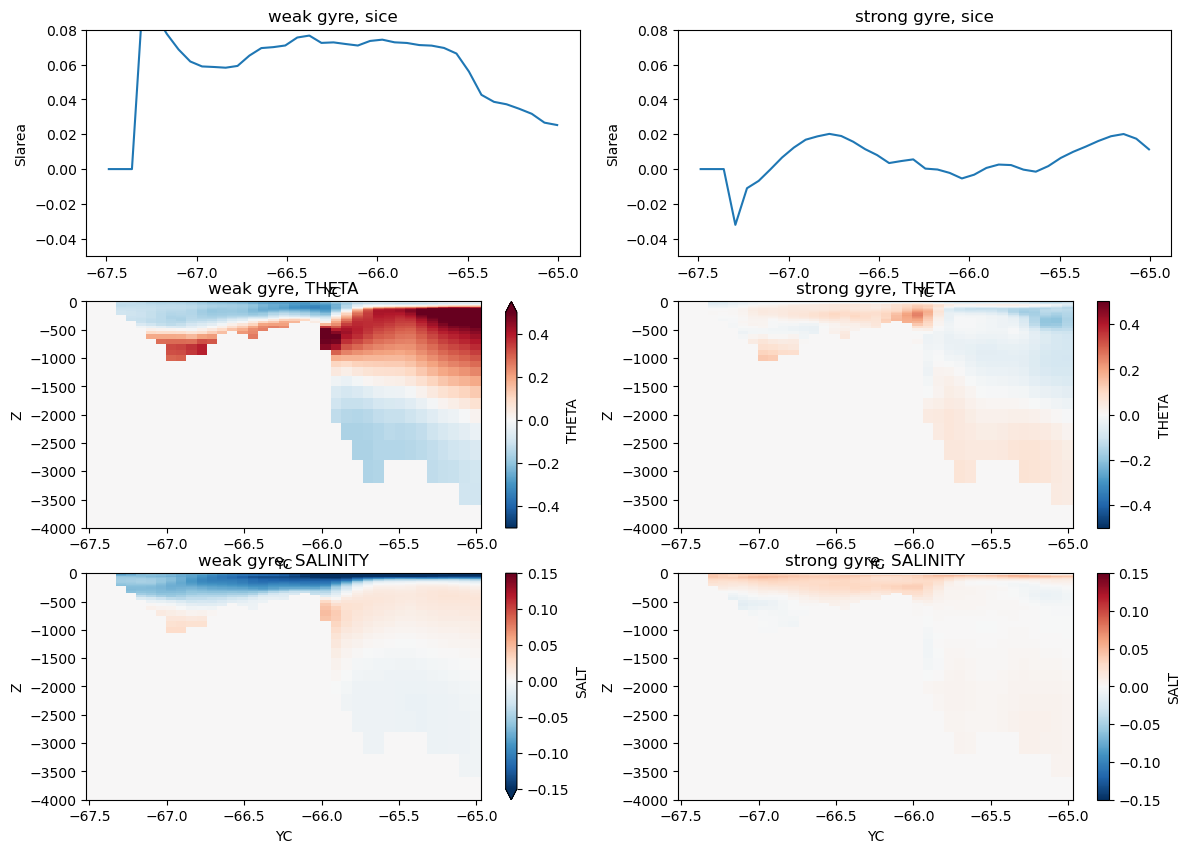

In [ ]:
fig,axs = plt.subplots(3,2,figsize=(14,10))

ax = axs[0]
top(dsa).SIarea.plot(ax=ax[0])
ax[0].set_title('weak gyre, sice')
ax[0].set_ylim([-0.05,0.08])

bot(dsa).SIarea.plot(ax=ax[1])
ax[1].set_title('strong gyre, sice')
ax[1].set_ylim([-0.05,0.08])

ax = axs[1]
top(dsa).THETA.plot(ax=ax[0],vmin=-0.5)
ax[0].set_title('weak gyre, THETA')
ax[0].set_ylim([-4000,0])

bot(dsa).THETA.plot(ax=ax[1],vmin=-0.5)
ax[1].set_title('strong gyre, THETA')
ax[1].set_ylim([-4000,0])

ax = axs[2]
top(dsa).SALT.plot(ax=ax[0],vmin=-0.15)
ax[0].set_title('weak gyre, SALINITY')
ax[0].set_ylim([-4000,0])

bot(dsa).SALT.plot(ax=ax[1],vmin=-0.15)
ax[1].set_title('strong gyre, SALINITY')
ax[1].set_ylim([-4000,0])

    


In [14]:
s = 'autumn'
run_for_idx(ssn_gh[s],0.25,ssn_sla[s],ssn_geos[s],'SLA autumn')
topboo, botboo, top, bot = get_topbot(idx,0.2)

NameError: name 'run_for_idx' is not defined

In [15]:
ssn_dsa = season_split(dsa)

NameError: name 'season_split' is not defined

NameError: name 'ssn_dsa' is not defined

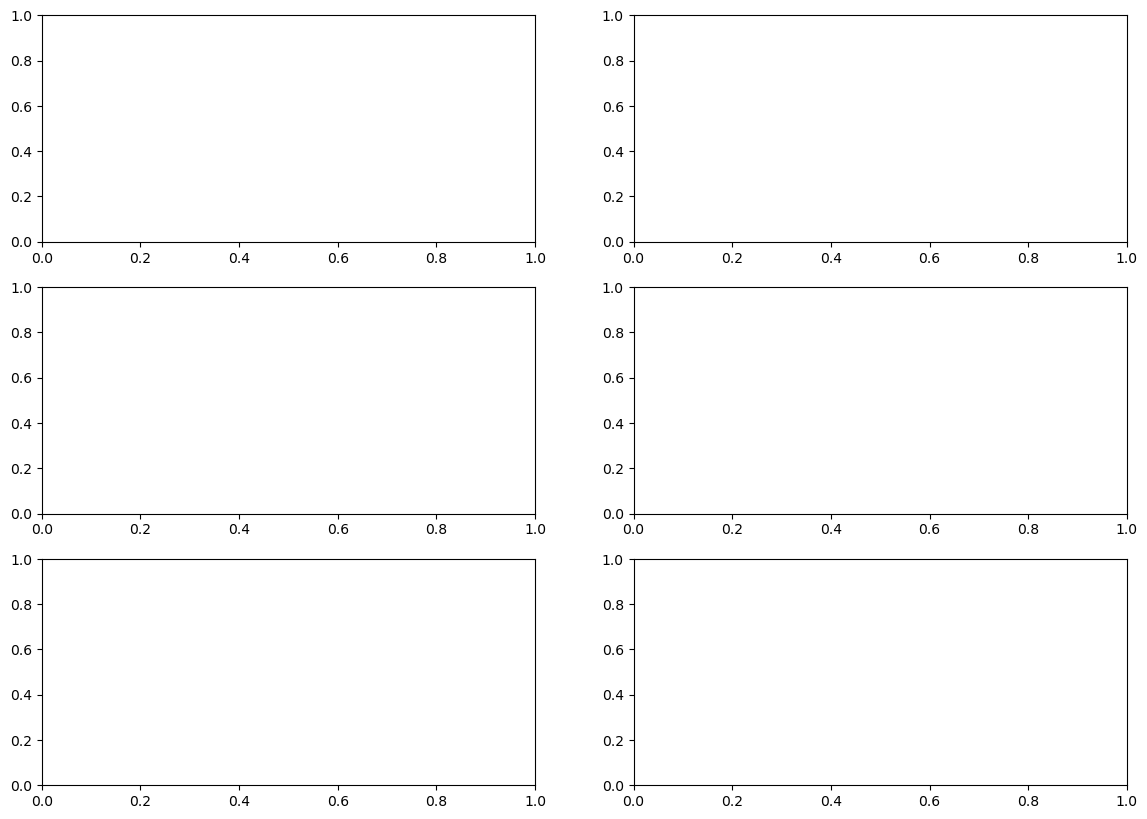

In [16]:
fig,axs = plt.subplots(3,2,figsize=(14,10))

z=-1000
dsw = ssn_dsa['winter']
ax = axs[0]
top(dsw).SIarea.plot(ax=ax[0])
ax[0].set_title('weak gyre, sice')
ax[0].set_ylim([-0.08,0.08])

bot(dsw).SIarea.plot(ax=ax[1])
ax[1].set_title('strong gyre, sice')
ax[1].set_ylim([-0.08,0.08])

ax = axs[1]
top(dsw).THETA.plot(ax=ax[0],vmin=-0.4)
ax[0].set_title('weak gyre, THETA')
ax[0].set_ylim([z,0])

bot(dsw).THETA.plot(ax=ax[1],vmin=-0.4)
ax[1].set_title('strong gyre, THETA')
ax[1].set_ylim([z,0])

ax = axs[2]
top(dsw).SALT.plot(ax=ax[0],vmin=-0.1)
ax[0].set_title('weak gyre, SALINITY')
ax[0].set_ylim([z,0])

bot(dsw).SALT.plot(ax=ax[1],vmin=-0.1)
ax[1].set_title('strong gyre, SALINITY')
ax[1].set_ylim([z,0])

    


In [ ]:
#compute cross shelf heat transport
ds['pressure'] = conversions.p_from_z(ds.Z,ds.YC.mean())
ds['asal'] = conversions.SA_from_SP(ds.SALT,ds.pressure,145,ds.YC)
ds['ctemp'] = conversions.CT_from_t(ds.asal,ds.THETA,ds.pressure)
ds['rho'] = density.rho(ds.asal,ds.ctemp,ds.pressure)

In [44]:
ds.load()

<xarray.Dataset> Size: 70MB
Dimensions:   (YC: 38, YG: 37, Z: 52, Zu: 52, Zl: 52, Zp1: 53, time: 803)
Coordinates: (12/23)
    XC        float64 8B 144.9
    XG        float64 8B 145.0
  * YC        (YC) float64 304B -67.49 -67.42 -67.36 ... -65.15 -65.08 -65.01
  * YG        (YG) float64 296B -67.46 -67.39 -67.33 ... -65.18 -65.11 -65.04
  * Z         (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu        (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
    ...        ...
    rAs       (YG) float64 296B 5.047e+07 5.074e+07 ... 6.082e+07 6.114e+07
    drC       (Zp1) float64 424B 2.1 4.6 5.45 6.4 ... 400.0 400.0 400.0 200.0
    drF       (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC     (Z, YC) float64 16kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW     (Z, YC) float64 16kB 0.0 0.0 0.0 0.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacS     (Z, YG) float64 15kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables: (12/14)
    THETA     (time, Z, YC) float32 6MB 0.0 0.0 0.0 -1.835 ... 0.0 0.0 0.0 0.0
    SALT      (time, Z, YC) float32 6MB 0.0 0.0 0.0 33.94 ... 0.0 0.0 0.0 0.0
    UVEL      (time, Z, YC) float32 6MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VVEL      (time, Z, YG) float32 6MB 0.0 0.0 0.0 -0.01539 ... 0.0 0.0 0.0 0.0
    WVEL      (time, Zl, YC) float32 6MB 0.0 0.0 0.0 -1.872e-06 ... 0.0 0.0 0.0
    ETAN      (time, YC) float32 122kB 0.0 0.0 0.0 ... -1.788 -1.776 -1.775
    ...        ...
    PHIBOT    (time, YC) float32 122kB -3.003 -3.012 -3.021 ... 3.102 3.096
    BLGMLD    (time, YC) float32 122kB 4.2 4.2 4.2 71.46 ... 13.03 13.16 14.6
    pressure  (Z) float64 416B 2.121 6.767 12.27 ... 5.524e+03 5.939e+03
    asal      (time, Z, YC) float64 13MB 0.0 0.0 0.0 34.1 ... 0.0 0.0 0.0 0.0
    ctemp     (time, Z, YC) float64 13MB 0.01538 0.01538 ... -0.1131 -0.1131
    rho       (time, Z, YC) float64 13MB 999.9 999.9 ... 1.028e+03 1.028e+03

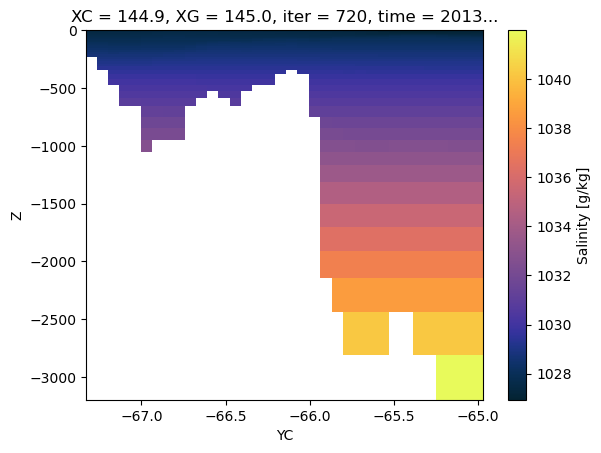

In [45]:
ds.where(-ds.Z < ds.Depth,drop=True).rho.isel(time=1).plot(y='Z',cmap=cmocean.cm.thermal)

In [46]:
# constants
rho0 = 1027.0    # kg/m3
cp = 3985.0      # J/kg/K

# variables
theta = ds["THETA"]   # (time, Z, YC)
salt  = ds["SALT"]
vvel  = ds["VVEL"]    # (time, Z, YG)

# grid metrics
rAs   = ds["rAs"]     # (YG)
drF   = ds["drF"]     # (Z)
hFacS = ds["hFacS"]   # (Z, YG)

# 1) average THETA to VVEL lat positions (staggered grid)
theta_on_v = 0.5 * (theta.sel(YC=ds["YC"].isel(YC=slice(0, -1))).rename({"YC":"YG"}) +
                    theta.sel(YC=ds["YC"].isel(YC=slice(1, None))).rename({"YC":"YG"}))



In [58]:
theta_on_v

<xarray.DataArray 'THETA' (time: 803, Z: 52, YG: 36)> Size: 6MB
array([[[ 0.       ,  0.       , -1.8349153, ..., -1.7581426,
         -1.7507364, -1.7450893],
        [ 0.       ,  0.       , -1.8324863, ..., -1.7568403,
         -1.7488524, -1.742588 ],
        [ 0.       ,  0.       , -1.8334951, ..., -1.7566311,
         -1.7482988, -1.7416645],
        ...,
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ]],

       [[ 0.       ,  0.       , -1.7846881, ..., -1.6832792,
         -1.6857036, -1.6748532],
        [ 0.       ,  0.       , -1.778847 , ..., -1.691125 ,
         -1.6882738, -1.6759872],
        [ 0.       ,  0.       , -1.7808115, ..., -1.6982332,
         -1.6919464, -1.677989 ],
...
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ]],

       [[ 0.       ,  0.       , -1.4632823, ..., -1.2450972,
         -1.2619165, -1.2714245],
        [ 0.       ,  0.       , -1.4586529, ..., -1.2351087,
         -1.2520581, -1.2619032],
        [ 0.       ,  0.       , -1.4521374, ..., -1.2303013,
         -1.2471539, -1.2572426],
        ...,
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ]]], dtype=float32)
Coordinates: (12/14)
  * YG       (YG) float64 288B -67.42 -67.36 -67.29 ... -65.22 -65.15 -65.08
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * time     (time) datetime64[ns] 6kB 2013-01-03T12:00:00 ... 2023-12-27T12:...
    XC       float64 8B 144.9
    XG       float64 8B 145.0
    iter     (time) int64 6kB 360 720 1080 1440 ... 288000 288360 288720 289080
    ...       ...
    rA       (YG) float64 288B 5.061e+07 5.088e+07 ... 6.066e+07 6.098e+07
    Depth    (YG) float64 288B 0.0 0.0 230.0 ... 3.15e+03 3.176e+03 3.32e+03
    rAw      (YG) float64 288B 5.061e+07 5.088e+07 ... 6.066e+07 6.098e+07
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC    (Z, YG) float64 15kB 0.0 0.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW    (Z, YG) float64 15kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0

In [56]:
theta_on_v * ds['VVEL']

<xarray.DataArray (time: 803, Z: 52, YG: 0)> Size: 0B
array([], shape=(803, 52, 0), dtype=float32)
Coordinates: (12/18)
  * YG       (YG) float64 0B 
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * time     (time) datetime64[ns] 6kB 2013-01-03T12:00:00 ... 2023-12-27T12:...
    XC       float64 8B 144.9
    XG       float64 8B 145.0
    iter     (time) int64 6kB 360 720 1080 1440 ... 288000 288360 288720 289080
    ...       ...
    hFacC    (Z, YG) float64 0B 
    hFacW    (Z, YG) float64 0B 
    dyC      (YG) float64 0B 
    dxG      (YG) float64 0B 
    rAs      (YG) float64 0B 
    hFacS    (Z, YG) float64 0B

In [53]:
ds.sel(YG=-65.5,method='nearest')# .integrate('Z')

<xarray.Dataset> Size: 65MB
Dimensions:    (YC: 38, Z: 52, Zu: 52, Zl: 52, Zp1: 53, time: 803)
Coordinates: (12/23)
  * YC         (YC) float64 304B -67.49 -67.42 -67.36 ... -65.15 -65.08 -65.01
    YG         float64 8B -65.53
  * Z          (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu         (Zu) int64 416B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50 51
  * Zl         (Zl) float64 416B 0.0 -4.2 -9.2 ... -4.8e+03 -5.2e+03 -5.6e+03
  * Zp1        (Zp1) float64 424B 0.0 -4.2 -9.2 ... -5.2e+03 -5.6e+03 -6e+03
    ...         ...
    rAs        float64 8B 5.892e+07
    drC        (Zp1) float64 424B 2.1 4.6 5.45 6.4 ... 400.0 400.0 400.0 200.0
    drF        (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC      (Z, YC) float64 16kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW      (Z, YC) float64 16kB 0.0 0.0 0.0 0.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacS      (Z) float64 416B 1.0 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables: (12/16)
    THETA      (time, Z, YC) float32 6MB 0.0 0.0 0.0 -1.835 ... 0.0 0.0 0.0 0.0
    SALT       (time, Z, YC) float32 6MB 0.0 0.0 0.0 33.94 ... 0.0 0.0 0.0 0.0
    UVEL       (time, Z, YC) float32 6MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VVEL       (time, Z) float32 167kB -0.001651 -0.04007 -0.04997 ... 0.0 0.0
    WVEL       (time, Zl, YC) float32 6MB 0.0 0.0 0.0 -1.872e-06 ... 0.0 0.0 0.0
    ETAN       (time, YC) float32 122kB 0.0 0.0 0.0 ... -1.788 -1.776 -1.775
    ...         ...
    pressure   (Z) float64 416B 2.121 6.767 12.27 ... 5.524e+03 5.939e+03
    asal       (time, Z, YC) float64 13MB 0.0 0.0 0.0 34.1 ... 0.0 0.0 0.0 0.0
    ctemp      (time, Z, YC) float64 13MB 0.01538 0.01538 ... -0.1131 -0.1131
    rho        (time, Z, YC) float64 13MB 999.9 999.9 ... 1.028e+03 1.028e+03
    thetav     (time, Z) float32 167kB nan nan nan nan nan ... nan nan nan nan
    thetavvel  (time, Z) float32 167kB nan nan nan nan nan ... nan nan nan nan

In [67]:
# 2) compute effective face area (2D: Z,YG)
#    area = rAs(YG) * drF(Z) * hFacS(Z,YG)
area = (drF * rAs).broadcast_like(hFacS) * hFacS
area


<xarray.DataArray (Z: 52, YG: 37)> Size: 15kB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.15423517e+08,
        2.16582180e+08, 2.17746941e+08, 2.18917783e+08, 2.20093077e+08,
        2.21274487e+08, 2.22462079e+08, 2.23655853e+08, 2.24855827e+08,
        2.26060336e+08, 2.27271112e+08, 2.28488138e+08, 2.29709766e+08,
        2.30937678e+08, 2.32171957e+08, 2.33412587e+08, 2.34657870e+08,
        2.35909554e+08, 2.37169420e+08, 2.38433989e+08, 2.39703280e+08,
        2.40979071e+08, 2.42261382e+08, 2.43550227e+08, 2.44845642e+08,
        2.46145878e+08, 2.47452716e+08, 2.48766190e+08, 2.50086317e+08,
        2.51413148e+08, 2.52744867e+08, 2.54083323e+08, 2.55428516e+08,
        2.56778664e+08],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.56456580e+08,
        2.57835940e+08, 2.59222560e+08, 2.60616420e+08, 2.62015580e+08,
        2.63422020e+08, 2.64835820e+08, 2.66256980e+08, 2.67685520e+08,
        2.69119460e+08, 2.70560860e+08, 2.72009700e+08, 2.73464020e+08,
        2.74925820e+08, 2.76395200e+08, 2.77872140e+08, 2.79354620e+08,
        2.80844720e+08, 2.82344560e+08, 2.83850000e+08, 2.85361060e+08,
        2.86879860e+08, 2.88406420e+08, 2.89940760e+08, 2.91482920e+08,
        2.93030820e+08, 2.94586580e+08, 2.96150240e+08, 2.97721820e+08,
        2.99301380e+08, 3.00886760e+08, 3.02480160e+08, 3.04081580e+08,
        3.05688900e+08],
...
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]])
Coordinates:
    XC       float64 8B 144.9
    XG       float64 8B 145.0
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
  * YG       (YG) float64 296B -67.46 -67.39 -67.33 ... -65.18 -65.11 -65.04
    dyC      (YG) float64 296B 7.104e+03 7.123e+03 ... 7.798e+03 7.819e+03
    dxG      (YG) float64 296B 7.104e+03 7.123e+03 ... 7.798e+03 7.819e+03
    rAs      (YG) float64 296B 5.047e+07 5.074e+07 ... 6.082e+07 6.114e+07
    hFacS    (Z, YG) float64 15kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0

In [ ]:
# 3) compute instantaneous heat flux per face
#    shape: (time, Z, YG)
Q_face = rho0 * cp * vvel * theta_on_v * area

# 4) select latitude band (65–66S)
lat_band = slice(-66, -65)   # southern lats are negative
Q_band = Q_face.sel(YG=lat_band)

# 5) integrate over lat, depth
F_time = Q_band.sum(dim=("Z", "YG"))  # (time,)

# convert to TW
F_time_TW = F_time / 1e12

print("Mean heat transport (65–66S, onto shelf positive northward):")
print(F_time_TW.mean().values, "TW")